In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class GridWorld:
    def __init__(self, size=4):
        self.size = size
        self.start_state = (0, 0)
        self.goal_state = (size-1, size-1)
        self.actions = ['up', 'down', 'left', 'right']
        self.reset()

    def reset(self):
        self.state = self.start_state
        return self.state

    def step(self, action):
        x, y = self.state

        if action == 'up':
            x = max(x-1, 0)
        elif action == 'down':
            x = min(x+1, self.size-1)
        elif action == 'left':
            y = max(y-1, 0)
        elif action == 'right':
            y = min(y+1, self.size-1)

        self.state = (x, y)

        if self.state == self.goal_state:
            return self.state, 10, True
        else:
            return self.state, -1, False


In [3]:
def epsilon_greedy(Q, state, actions, epsilon):
    if random.random() < epsilon:
        return random.choice(actions)
    return actions[np.argmax(Q[state])]

In [4]:
def td_zero_prediction(env, episodes=500, alpha=0.1, gamma=0.9):
    V = np.zeros((env.size, env.size))

    for ep in range(episodes):
        state = env.reset()
        done = False

        while not done:
            action = random.choice(env.actions)
            next_state, reward, done = env.step(action)

            x, y = state
            nx, ny = next_state

            V[x, y] += alpha * (reward + gamma * V[nx, ny] - V[x, y])
            state = next_state

    return V

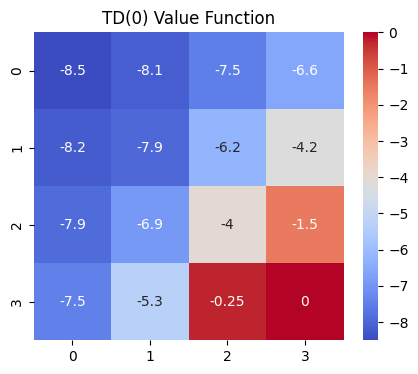

In [5]:
env = GridWorld()
V_td = td_zero_prediction(env)

plt.figure(figsize=(5, 4))
sns.heatmap(V_td, annot=True, cmap="coolwarm")
plt.title("TD(0) Value Function")
plt.show()

In [6]:
def sarsa(env, episodes=1000, alpha=0.1, gamma=0.9, epsilon=0.1):
    Q = {(i, j): np.zeros(len(env.actions))
         for i in range(env.size) for j in range(env.size)}

    rewards = []

    for ep in range(episodes):
        state = env.reset()
        action = epsilon_greedy(Q, state, env.actions, epsilon)
        done = False
        total_reward = 0

        while not done:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy(Q, next_state, env.actions, epsilon)

            Q[state][env.actions.index(action)] += alpha * (
                reward + gamma * Q[next_state][env.actions.index(next_action)]
                - Q[state][env.actions.index(action)]
            )

            state = next_state
            action = next_action
            total_reward += reward

        rewards.append(total_reward)

    return Q, rewards

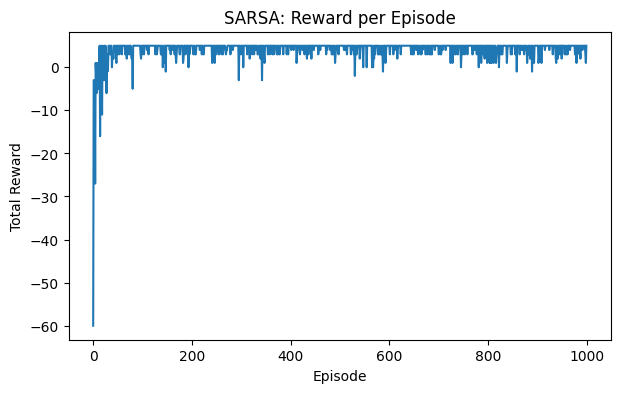

In [7]:
Q_sarsa, rewards_sarsa = sarsa(env)

plt.figure(figsize=(7, 4))
sns.lineplot(x=range(len(rewards_sarsa)), y=rewards_sarsa)
plt.title("SARSA: Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

In [8]:
def q_learning(env, episodes=1000, alpha=0.1, gamma=0.9, epsilon=0.1):
    Q = {(i, j): np.zeros(len(env.actions))
         for i in range(env.size) for j in range(env.size)}

    rewards = []

    for ep in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy(Q, state, env.actions, epsilon)
            next_state, reward, done = env.step(action)

            Q[state][env.actions.index(action)] += alpha * (
                reward + gamma * np.max(Q[next_state])
                - Q[state][env.actions.index(action)]
            )

            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    return Q, rewards

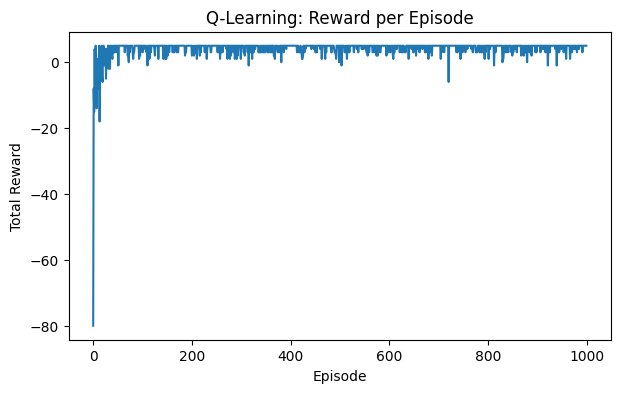

In [9]:
Q_ql, rewards_ql = q_learning(env)

plt.figure(figsize=(7, 4))
sns.lineplot(x=range(len(rewards_ql)), y=rewards_ql)
plt.title("Q-Learning: Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

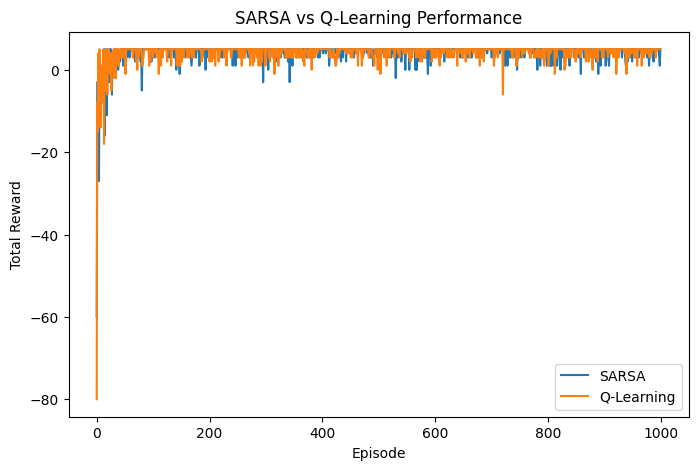

In [10]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=range(len(rewards_sarsa)), y=rewards_sarsa, label="SARSA")
sns.lineplot(x=range(len(rewards_ql)), y=rewards_ql, label="Q-Learning")
plt.title("SARSA vs Q-Learning Performance")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.show()